✅ Label encoder saved to 'label_encoder.pkl'
Shape of a single chromagram: (12, 1292)
Inferred Input Shape: (12, 1292)


c:\Users\Tanushkumaaar\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 12, 32)         │       124,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 95)             │        12,255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,343 (942.75 KB)

 Trainable params: 241,343 (942.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/64
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.0621 - loss: 4.1396 - val_accuracy: 0.1041 - val_loss: 3.7511 - learning_rate: 0.0010
Epoch 2/64
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1086 - loss: 3.8610 - val_accuracy: 0.1616 - val_loss: 3.4469 - learning_rate: 0.0010
Epoch 3/64
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1682 - loss: 3.4075 - val_accuracy: 0.2301 - val_loss: 3.1606 - learning_rate: 0.0010
Epoch 4/64
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2321 - loss: 3.0853 - val_accuracy: 0.2959 - val_loss: 2.7453 - learning_rate: 0.0010
Epoch 5/64
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2973 - loss: 2.7224 - val_accuracy: 0.3205 - val_loss: 2.6173 - learning_rate: 0.0010
Epoch 6/64
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3481 - loss: 2.4300 - val_accuracy: 0.3315 - val_loss: 2.4546 - learning_rate: 0.0010
Epoch 7/64
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4000 - loss: 2.2349 -

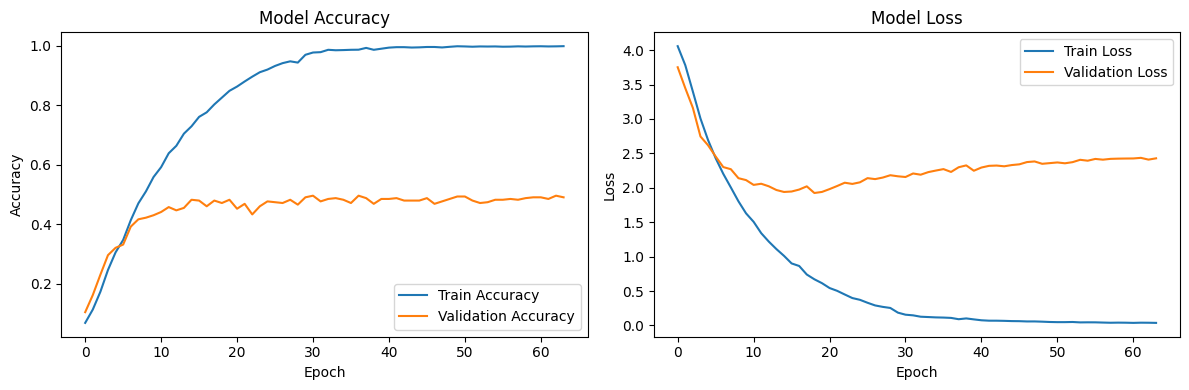

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


ValueError: Number of classes, 93, does not match size of target_names, 95. Try specifying the labels parameter

In [1]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import pickle
# import seaborn as sns

LABEL_ENCODER_PATH = "label_encoder.pkl"
TRAINING_HISTORY_PATH = "training_history.npy"

# --- Load the preprocessed data ---
data = np.load("./chromagrams.npz")
chromagrams = data['chromagrams']
labels = data['labels']

# --- Encode the labels ---
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
num_classes = len(np.unique(encoded_labels))
categorical_labels = to_categorical(encoded_labels, num_classes=num_classes)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
print("✅ Label encoder saved to 'label_encoder.pkl'")

# --- Split the data into training and testing sets ---
X = np.array(chromagrams)
y = np.array(categorical_labels)

# Let's check the shape of one of your chromagrams to understand the dimensions
print("Shape of a single chromagram:", X[0].shape)

# We don't need the channel dimension here initially
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- Build the CNN-LSTM Model (Revised for 1D Convolution) ---
def build_cnn_lstm_model(input_shape, num_classes):
    model = Sequential()

    # Use Conv1D as we are processing each of the 12 chroma features over time
    model.add(Conv1D(32, kernel_size=3, activation='relu', padding='same', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    model.add(LSTM(128, return_sequences=False, recurrent_dropout=0.1))
    model.add(Dropout(0.3))

    model.add(Dense(num_classes, activation='softmax'))


    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Determine the input shape for a single time series (a single chromagram)
# It should be (time_steps, num_chroma_features)
time_steps = X_train.shape[1]
num_chroma_features = X_train.shape[2] if len(X_train.shape) > 2 else 12 # Assuming 12 if the shape is (num_samples, time_steps)
input_shape = (time_steps, num_chroma_features)

print("Inferred Input Shape:", input_shape)
model = build_cnn_lstm_model(input_shape, num_classes)
model.summary()

# --- Train the model ---
epochs = 64  # You can adjust this
batch_size = 16
lrs = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    verbose=0,
    mode="auto",
    min_delta=0.0001,
    cooldown=0,
    min_lr=0.0001
    )
es = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, shuffle=True, callbacks=[lrs])

np.save(TRAINING_HISTORY_PATH, history.history)

# --- Evaluate the model ---
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# --- Plot Training History ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# --- Make Predictions and Plot Confusion Matrix ---
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

report = classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_)
print("\nClassification Report:")
print(report)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# --- Function for Prediction on a New Audio File (Illustrative) ---
def predict_raga(audio_path, sample_rate, trained_model, label_encoder):
    chroma = get_chromagram(audio_path, sample_rate)
    # Ensure the chroma has the same time steps as the training data (you might need to pad or truncate)
    # For simplicity, we'll assume it does or handle it appropriately
    chroma_reshaped = chroma[np.newaxis, ...] # Add batch dimension
    prediction = trained_model.predict(chroma_reshaped)
    predicted_class_index = np.argmax(prediction)
    predicted_raga = label_encoder.classes_[predicted_class_index]
    print(f"Predicted Raga for {os.path.basename(audio_path)}: {predicted_raga}")
    return predicted_raga

# Example of how to use the prediction function (you'd need a new audio file)
# new_audio_file = "path/to/your/new_audio.mp3"
# predicted_raga = predict_raga(new_audio_file, SAMPLE_RATE, model, label_encoder)

In [ ]:
np.savez history.history

In [ ]:
model.save("raga_model5.keras")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
32